# 이송장치 센서 시계열 RAG: Other/metadata + SigLIP2 + Qdrant + Qwen3-VL

**13번 노트북**이 다루는 **프레임 단위 열화상 Visual RAG**를 확장해,
`Other/metadata/` CSV의 **트렌드·외부센서·열화상 최대온도**를 포함한 **세션 시계열**을 검색·분석합니다.

### 이 노트북에서 배우는 것

- **Time-Series RAG**: 한 시점 이미지가 아니라 **시간에 따른 센서 변화**를 검색하는 RAG
- **EAV 메타데이터**: 헤더 없는 4열 CSV를 파싱해 trend·ir_max 등을 추출하는 방법
- **슬라이딩 윈도우**: 긴 시계열을 검색 가능한 **한글 요약 문장**으로 자르는 기법
- **하이브리드 RAG**: 시계열 hit → 대표 열화상 PNG → Qwen3-VL로 연결하는 패턴

## 전체 흐름

```
ZIP → data/conveyor_condition_monitoring/ (이미 있으면 스킵)
       ↓
Other/metadata EAV CSV 파싱 + 세션별 시계열 테이블
       ↓
슬라이딩 윈도우 → 한글 자연어 요약 청크
       ↓
SigLIP2 텍스트 임베딩 → Qdrant (시계열 컬렉션)
       ↓
한글 Query → 시계열 구간 Top-k 검색
       ↓
동일 sample_id 열화상 PNG 연계 (13번 manifest)
       ↓
Qwen3-VL 분석 (시계열 요약 + 열화상)
```

| 단계 | 역할 |
|------|------|
| **Other/metadata** | 샘플별 EAV 메타 (trend, ir_max, 외부온습도) |
| **세션 시계열** | `sample_id` 타임스탬프 정렬 → NTC·CT·state 추이 |
| **윈도우 요약** | 30샘플 구간을 한글 문장으로 변환 (검색용 문서) |
| **SigLIP2** | 한글 질문 ↔ 시계열 요약 텍스트 임베딩 |
| **Qdrant** | 시계열 컬렉션 (13번 열화상 컬렉션과 분리) |
| **하이브리드** | 시계열 hit → 대표 열화상 PNG + Qwen3-VL |

### 13번·02번과의 관계

| 구분 | 02번 | 13번 | **14번 (이 노트북)** |
|------|------|------|---------------------|
| 데이터 | 가상 20프레임 | 실측 BIN 스냅샷 | **세션 시계열 + metadata** |
| 센서 | frame별 1행 | sample별 1행 | **윈도우 구간 추이·trend** |
| 검색 | ChromaDB 이미지 | Qdrant 열화상 | **Qdrant 시계열 텍스트** |
| 메타 소스 | sensor.csv | 세션 wide CSV | **Other/metadata EAV** |

> **사전 조건**: 프로젝트 루트에 `Conveyor_Condition_Monitoring.zip` 배치.
> 아래 **ZIP 압축 해제** 셀에서 자동 해제합니다 (이미 추출됐으면 스킵).


### 모듈·데이터 참조

이 노트북을 처음 실행할 때 **어떤 파일·폴더가 필요한지** 정리한 표입니다.
14번은 13번과 **같은 데이터 폴더**를 공유하며, 시계열 전용 캐시·Qdrant 컬렉션을 추가로 만듭니다.

📄 **[00_모듈_참조.md](00_모듈_참조.md)** · 선행: **[13_conveyor_condition_monitoring_visual_rag.ipynb](13_conveyor_condition_monitoring_visual_rag.ipynb)**

| 구성요소 | 경로 |
|----------|------|
| ZIP 파일 | `Conveyor_Condition_Monitoring.zip` (프로젝트 루트) |
| 원천 데이터 | `data/conveyor_condition_monitoring/` (13번과 공유) |
| 시계열 메타 | `data/conveyor_condition_monitoring/Other/metadata/*.csv` |
| 열화상 PNG | `data/conveyor_condition_monitoring/thermal_images/` (13번 생성) |
| Qdrant DB | `data/conveyor_condition_monitoring/qdrant_db/` |
| 시계열 캐시 | `data/conveyor_condition_monitoring/timeseries_windows.json` |


## 0. 환경 설정

이 셀에서 **경로·윈도우·컬렉션명**을 한곳에 모읍니다. 아래 셀들은 여기서 정의한 변수를 공유합니다.

### Time-Series RAG란?

- **13번**: 한 시점의 열화상 PNG를 검색합니다.
- **14번**: **시간 축**으로 이어진 센서·상태 변화를 **한글 요약 문장**으로 만들고, 그 문장을 검색합니다.
- 질의 예: *"CT1 전류가 급상승한 구간"*, *"NTC 온도가 계속 오른 세션"*

| 기술 | 설명 |
|------|------|
| **pandas** | 세션별 시계열 DataFrame 구축·윈도우 슬라이싱 |
| **SigLIP2** | 한글 질문 ↔ 시계열 요약 **텍스트** 임베딩 (이미지 없음) |
| **Qdrant** | 시계열 전용 컬렉션 (`conveyor_timeseries_siglip2`) |
| **Qwen3-VL** | 검색 hit의 시계열 요약 + 대표 열화상을 종합 분석 |

| 변수 | 의미 | 초보자 팁 |
|------|------|-----------|
| `DEMO_MODE` | 세션 수·윈도우 수 제한 | 첫 실행·GPU 메모리 부족 시 `True` |
| `MAX_SESSIONS` | DEMO 시 인덱싱할 최대 세션 수 | 4면 빠른 확인, 전체는 35세션 |
| `WINDOW_SIZE` | 윈도우 길이 (샘플 수, 약 1초/샘플) | 30 ≈ 30초 구간 |
| `WINDOW_STEP` | 윈도우 이동 간격 | 15면 50% 겹침 |
| `TS_COLLECTION_NAME` | Qdrant 시계열 전용 컬렉션명 | 13번 열화상 컬렉션과 분리 |


In [1]:
# !pip install qdrant-client transformers accelerate torch pillow tqdm matplotlib pandas
# 13번 노트북과 동일 패키지. Colab/새 환경에서 최초 1회 실행.
# Qwen3-VL 분석까지 쓰려면 qwen-vl-utils도 추가 설치.


In [2]:
# --- 표준 라이브러리 ---
import csv       # 센서 CSV·EAV metadata 읽기
import gc        # SigLIP2 해제 후 GPU 메모리 정리
import json      # 윈도우 캐시·라벨 JSON
import shutil    # ZIP 추출·폴더 삭제
import sys       # conveyor_analyze 모듈 path 등록
import uuid      # Qdrant 포인트 ID (window_id → UUID5)
import zipfile   # Conveyor ZIP 해제
from pathlib import Path

# --- 데이터·시각화 ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from PIL import Image          # 열화상 PNG 로드 (하이브리드 시각화)
from qdrant_client import QdrantClient, models
from tqdm.auto import tqdm     # SigLIP2 배치 인덱싱 진행률
from transformers import AutoModel, AutoProcessor, Qwen3VLForConditionalGeneration

# --- 경로 (13번과 동일) ---
ROOT = Path(".").resolve()
ZIP_PATH = ROOT / "Conveyor_Condition_Monitoring.zip"
DATA_DIR = ROOT / "data" / "conveyor_condition_monitoring"
METADATA_DIR = DATA_DIR / "Other" / "metadata"   # EAV trend·ir_max
IMAGES_DIR = DATA_DIR / "thermal_images"         # 13번 BIN→PNG 결과
QDRANT_DIR = DATA_DIR / "qdrant_db"
MANIFEST_PATH = DATA_DIR / "manifest.json"
WINDOWS_CACHE = DATA_DIR / "timeseries_windows.json"  # 윈도우 청크 JSON 캐시

# matplotlib 한글 폰트 (02·13번과 동일 모듈)
CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"
sys.path.insert(0, str(CONVEYOR_ANALYZE))
from conveyor_rag.plot_utils import setup_korean_matplotlib

_korean_font = setup_korean_matplotlib()

# --- 모델·벡터 DB ---
SIGLIP2_MODEL_ID = "google/siglip2-so400m-patch14-384"
QWEN_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
TS_COLLECTION_NAME = "conveyor_timeseries_siglip2"  # 13번 열화상 컬렉션과 별도
EMBED_DIM = 1152

# --- 시계열 RAG 설정 ---
DEMO_MODE = True
MAX_SESSIONS = 4          # DEMO: 4세션만 (전체 35세션)
WINDOW_SIZE = 30          # 약 30초 구간 (duration_time=1초/샘플)
WINDOW_STEP = 15          # 윈도우 50% 겹침
TOP_K = 3
REBUILD_TS_INDEX = True   # True면 시계열 Qdrant 컬렉션 재구축
SIGLIP2_BATCH_SIZE = 16

STATE_LABELS = {"0": "정상", "1": "주의", "2": "경고", "3": "이상"}
TREND_LABELS = {"-1": "하락", "0": "유지", "1": "상승"}

# 세션 폴더 접두사: TS_/VS_=센서, TL_/VL_=라벨
SENSOR_SESSION_PREFIXES = ("TS_", "VS_")
LABEL_SESSION_PREFIXES = ("TL_", "VL_")

device = "cuda" if torch.cuda.is_available() else "cpu"

# 지연 로딩·싱글톤용 (셀 재실행 시 재사용)
siglip_encoder = None
qdrant_client = None
qwen_model = None
qwen_processor = None

QDRANT_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"ZIP: {ZIP_PATH} ({'존재' if ZIP_PATH.exists() else '없음'})")
print(f"Device: {device}")
print(f"METADATA_DIR: {METADATA_DIR} ({'존재' if METADATA_DIR.exists() else '없음'})")
print(f"DEMO_MODE={DEMO_MODE}, MAX_SESSIONS={MAX_SESSIONS}")


ROOT: C:\MyCursorLab\09_Visual_RAG
ZIP: C:\MyCursorLab\09_Visual_RAG\Conveyor_Condition_Monitoring.zip (존재)
Device: cpu
METADATA_DIR: C:\MyCursorLab\09_Visual_RAG\data\conveyor_condition_monitoring\Other\metadata (없음)
DEMO_MODE=True, MAX_SESSIONS=4


## ZIP 압축 해제

프로젝트 루트의 `Conveyor_Condition_Monitoring.zip`을 `data/conveyor_condition_monitoring/`에 풉니다.

- **이미 추출됨** (`.bin` 존재 + 한글 폴더명 정상) → 스킵
- **한글 폴더명 깨짐** → `Training`/`Validation`/`Other`만 지우고 재추출 (`thermal_images`, `qdrant_db`는 유지)
- Windows ZIP은 **CP949** 폴더명 → `decode_zip_filename()`으로 복원

13번 노트북과 동일 ZIP·경로를 사용합니다.


In [3]:
def decode_zip_filename(name: str) -> str:
    """Windows CP949 ZIP 엔트리명 → UTF-8 한글 파일명 복원."""
    if name.isascii():
        return name
    # 이미 정상 한글이면 그대로 반환
    if any("\uac00" <= ch <= "\ud7a3" for ch in name):
        return name
    # Python zipfile은 CP949 파일명을 cp437 유니코드로 잘못 디코딩 → cp949로 재해석
    for encoding in ("cp949", "euc-kr"):
        try:
            return name.encode("cp437").decode(encoding)
        except (UnicodeDecodeError, UnicodeEncodeError):
            continue
    return name


def decode_zip_path(raw_name: str) -> Path:
    """ZIP 엔트리 경로의 각 폴더·파일명을 한글로 복원."""
    parts = raw_name.replace("\\", "/").strip("/").split("/")
    return Path(*[decode_zip_filename(p) for p in parts if p])


def has_broken_folder_names(dest: Path) -> bool:
    """01.원천데이터 / 02.라벨링데이터 한글명이 깨졌는지 확인."""
    for split in ("Training", "Validation"):
        split_dir = dest / split
        if not split_dir.exists():
            continue
        for child in split_dir.iterdir():
            if not child.is_dir():
                continue
            if child.name.startswith("01.") and "원천" not in child.name:
                return True
            if child.name.startswith("02.") and "라벨" not in child.name:
                return True
    return False


def is_dataset_extracted(dest: Path) -> bool:
    """BIN 파일이 있고 한글 폴더명이 정상이면 추출 완료."""
    if not dest.exists():
        return False
    if next(dest.rglob("*.bin"), None) is None:
        return False
    return not has_broken_folder_names(dest)


def extract_dataset_zip(zip_path: Path, dest: Path, force: bool = False) -> bool:
    """ZIP을 dest에 압축 해제 (CP949 한글 폴더명 복원). 이미 정상 추출됐으면 스킵."""
    if not force and is_dataset_extracted(dest):
        print(f"이미 추출됨 — 압축 해제 스킵: {dest}")
        return False

    if not zip_path.exists():
        raise FileNotFoundError(
            f"{zip_path} 없음.\n"
            "프로젝트 루트에 Conveyor_Condition_Monitoring.zip을 배치하세요."
        )

    if has_broken_folder_names(dest):
        print("깨진 한글 폴더명 감지 → 데이터 폴더를 비우고 다시 추출합니다.")
    elif force and dest.exists():
        print("force=True → 데이터 폴더를 비우고 다시 추출합니다.")

    # thermal_images·qdrant_db는 유지, ZIP 원본 데이터만 교체
    if dest.exists():
        for sub in ("Training", "Validation", "Other", "extraction_info.json"):
            p = dest / sub
            if p.is_dir():
                shutil.rmtree(p)
            elif p.exists():
                p.unlink()
    dest.mkdir(parents=True, exist_ok=True)

    count = 0
    with zipfile.ZipFile(zip_path) as zf:
        for raw_name in zf.namelist():
            if raw_name.endswith("/"):
                continue
            out_path = dest / decode_zip_path(raw_name)
            if out_path.exists():
                continue
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(raw_name) as src, open(out_path, "wb") as dst:
                shutil.copyfileobj(src, dst)
            count += 1

    if not (dest / "Training").exists():
        subdirs = [p for p in dest.iterdir() if p.is_dir() and p.name not in ("thermal_images", "qdrant_db")]
        if len(subdirs) == 1 and (subdirs[0] / "Training").exists():
            wrapper = subdirs[0]
            for item in wrapper.iterdir():
                target = dest / item.name
                if target.exists():
                    shutil.rmtree(target) if target.is_dir() else target.unlink()
                shutil.move(str(item), str(dest))
            wrapper.rmdir()

    print(f"ZIP 추출 완료: {dest} ({count}개 파일)")
    return True


extracted = extract_dataset_zip(ZIP_PATH, DATA_DIR)
if not next(DATA_DIR.rglob("*.bin"), None):
    raise RuntimeError("데이터 추출 실패. ZIP에 Training/Validation 및 .bin 파일이 있는지 확인하세요.")

n_bins = len(list(DATA_DIR.rglob("*.bin")))
n_meta = len(list(METADATA_DIR.glob("*.csv"))) if METADATA_DIR.exists() else 0
print(f"BIN {n_bins:,}개, Other/metadata CSV {n_meta:,}개")


ZIP 추출 완료: C:\MyCursorLab\09_Visual_RAG\data\conveyor_condition_monitoring (46901개 파일)
BIN 11,491개, Other/metadata CSV 12,427개


## 1. 데이터 준비

위 **ZIP 압축 해제** 셀 실행 후, `scan_dataset_records()`로 전체 샘플을 스캔하고
`Other/metadata/{sample_id}.csv`와 조인합니다.

### sample_id가 연결 고리

- `sample_id` 하나가 BIN·세션 CSV·JSON 라벨·Other/metadata CSV를 연결합니다.
- 14번은 13번과 **같은 데이터 폴더**를 쓰며, 시계열·metadata 병합을 추가합니다.

| 소스 | 형식 | 13번 | 14번 |
|------|------|------|------|
| 세션 wide CSV | NTC, CT1… 1행 | 사용 | 사용 |
| Other/metadata | EAV 4열 | 미사용 | **trend, ir_max, 외부센서** |
| sample_id | `agv01_0901_081240` | 식별자 | **시간 정렬 키** |


In [4]:
def find_session_roots(dest: Path, prefixes: tuple[str, ...]) -> list[tuple[str, Path]]:
    """Training/Validation 아래 센서(TS_)·라벨(TL_) 세션 루트 탐색."""
    roots = []
    for split in ("Training", "Validation"):
        split_dir = dest / split
        if not split_dir.exists():
            continue
        for child in sorted(split_dir.iterdir()):
            if not child.is_dir():
                continue
            # 하위에 TS_agv_... 같은 세션 폴더가 있으면 원천/라벨 루트
            if any(p.is_dir() and p.name.startswith(prefixes) for p in child.iterdir()):
                roots.append((split, child))
    return roots


def load_label_state(label_dirs: list[Path], sample_id: str) -> str | None:
    """JSON 라벨에서 열화 state(0~3) 추출."""
    for label_dir in label_dirs:
        json_path = label_dir / f"{sample_id}.json"
        if not json_path.exists():
            continue
        data = json.loads(json_path.read_text(encoding="utf-8"))
        for ann in data.get("annotations", []):
            for tag in ann.get("tagging", []):
                return str(tag.get("state", ""))
    return None


def read_sensor_row(csv_path: Path) -> dict:
    """세션 wide CSV 1행 → float dict (NTC, CT1 등)."""
    with csv_path.open(encoding="utf-8") as f:
        row = next(csv.DictReader(f), {})
    return {k: float(v) if v else 0.0 for k, v in row.items()}


def scan_dataset_records() -> list[dict]:
    """전체 BIN·CSV·라벨을 스캔해 sample_id별 레코드 목록 생성."""
    sensor_roots = find_session_roots(DATA_DIR, SENSOR_SESSION_PREFIXES)
    label_roots = find_session_roots(DATA_DIR, LABEL_SESSION_PREFIXES)
    label_by_split = {split: root for split, root in label_roots}
    records = []
    for split, sensor_root in sensor_roots:
        label_root = label_by_split.get(split)
        for session_dir in sorted(sensor_root.iterdir()):
            if not session_dir.is_dir():
                continue
            # TS_agv_01 → TL_agv_01 라벨 폴더 매핑
            label_prefix = session_dir.name.replace("TS_", "TL_").replace("VS_", "VL_")
            label_dirs = [label_root / label_prefix] if label_root and (label_root / label_prefix).exists() else []
            for bin_path in sorted(session_dir.glob("*.bin")):
                sample_id = bin_path.stem
                csv_path = session_dir / f"{sample_id}.csv"
                if not csv_path.exists():
                    continue
                state = load_label_state(label_dirs, sample_id)
                sensor = read_sensor_row(csv_path)
                png_rel = f"{split}/{session_dir.name}/{sample_id}.png"
                records.append({
                    "sample_id": sample_id,
                    "split": split,
                    "session": session_dir.name,
                    "bin_path": str(bin_path),
                    "image_path": str(IMAGES_DIR / png_rel),
                    "state": state or "",
                    "state_label": STATE_LABELS.get(state or "", "미라벨"),
                    "ntc": sensor.get("NTC", 0),
                    "pm10": sensor.get("PM10", 0),
                    "ct1": sensor.get("CT1", 0),
                    "ct2": sensor.get("CT2", 0),
                })
    return records


# --- 데이터 존재 확인 및 스캔 ---
if not METADATA_DIR.exists():
    raise FileNotFoundError(
        f"{METADATA_DIR} 없음. 위 ZIP 압축 해제 셀을 먼저 실행하세요."
    )

all_records = scan_dataset_records()
print(f"전체 샘플: {len(all_records):,}건, 세션: {pd.DataFrame(all_records)['session'].nunique()}개")
print(f"Other/metadata CSV: {len(list(METADATA_DIR.glob('*.csv'))):,}개")


전체 샘플: 11,491건, 세션: 35개
Other/metadata CSV: 12,427개


## 2. Other/metadata EAV 파싱

`Other/metadata/{sample_id}.csv`는 **헤더 없는 4열 EAV**(Entity-Attribute-Value) 형식입니다.
wide CSV에는 없는 **trend(변화 방향)·열화상 최대온도·외부 온습도**가 여기에 있습니다.

```
section, group, key, value
sensor_data,NTC,value,29.0
sensor_data,NTC,trend,1
ir_data,temp_max,value_TGmx,44.38
```

| 필드 | 의미 |
|------|------|
| `trend` | 센서 변화 방향 (-1 하락, 0 유지, 1 상승) |
| `ir_data.temp_max` | 열화상 픽셀 최대 온도(℃) |
| `external_data` | 설치 환경 온도·습도·조도 |


In [5]:
def parse_metadata_eav(path: Path) -> dict:
    """Other/metadata EAV CSV → section/group/key 중첩 dict."""
    result: dict = {"meta_info": {}, "sensor_data": {}, "ir_data": {}, "external_data": {}}
    with path.open(encoding="utf-8", newline="") as f:
        for row in csv.reader(f):
            if len(row) < 3:
                continue
            section = row[0]
            if section == "meta_info" and len(row) == 3:
                result["meta_info"][row[1]] = row[2]
            elif len(row) >= 4:
                group, key, value = row[1], row[2], row[3]
                result.setdefault(section, {}).setdefault(group, {})[key] = value
    return result


def enrich_record_from_metadata(rec: dict) -> dict:
    """wide CSV 레코드 + Other/metadata trend·ir·외부센서 병합."""
    meta_path = METADATA_DIR / f"{rec['sample_id']}.csv"
    out = dict(rec)
    if not meta_path.exists():
        return out
    meta = parse_metadata_eav(meta_path)
    mi = meta.get("meta_info", {})
    out["collection_time"] = mi.get("collection_time", "")
    out["collection_date"] = mi.get("collection_date", "")
    for sensor in ("NTC", "PM10", "CT1", "CT2"):
        sd = meta.get("sensor_data", {}).get(sensor, {})
        if "trend" in sd:
            out[f"{sensor.lower()}_trend"] = int(float(sd["trend"]))
    ir = meta.get("ir_data", {}).get("temp_max", {})
    if "value_TGmx" in ir:
        out["ir_max"] = float(ir["value_TGmx"])
    ext = meta.get("external_data", {})
    if "ex_temperature" in ext:
        out["ex_temp"] = float(ext["ex_temperature"].get("value", 0) or 0)
    if "ex_humidity" in ext:
        out["ex_humidity"] = float(ext["ex_humidity"].get("value", 0) or 0)
    return out


def sample_sort_key(sample_id: str) -> int:
    """agv01_0901_081240 → 0901081240 정수 키 (세션 내 시간 정렬)."""
    parts = sample_id.split("_")
    return int(parts[-2] + parts[-1].zfill(6))


# --- 샘플 1건 파싱 확인 ---
sample_rec = enrich_record_from_metadata(all_records[0])
meta_sample = parse_metadata_eav(METADATA_DIR / f"{sample_rec['sample_id']}.csv")
print(f"sample_id: {sample_rec['sample_id']}")
print(f"  NTC={sample_rec['ntc']}, trend={sample_rec.get('ntc_trend')}, ir_max={sample_rec.get('ir_max')}")
print(f"  collection_time={sample_rec.get('collection_time')}")


sample_id: agv01_0901_081240
  NTC=29.0, trend=1, ir_max=44.38
  collection_time=08:12:40


## 3. 세션별 시계열 테이블 구축

세션(`TS_agv_01_...`) 단위로 `sample_id`를 시간순 정렬한 DataFrame을 만듭니다.
DEMO_MODE이면 `MAX_SESSIONS`개 세션만 사용합니다.

### 왜 세션 단위인가?

- 한 세션 = AGV 한 번의 주행·측정 구간입니다.
- 시계열 RAG는 **세션 안에서** NTC·CT1이 어떻게 변했는지를 검색합니다.


In [6]:
def build_session_dataframe(records: list[dict], max_sessions: int | None = None) -> pd.DataFrame:
    """레코드 목록 → 세션·시간 정렬 DataFrame. max_sessions로 DEMO 제한."""
    enriched = [enrich_record_from_metadata(r) for r in records]
    df = pd.DataFrame(enriched)
    df["sort_key"] = df["sample_id"].map(sample_sort_key)
    df = df.sort_values(["session", "sort_key"]).reset_index(drop=True)
    if max_sessions is not None:
        sessions = df["session"].unique()[:max_sessions]
        df = df[df["session"].isin(sessions)].reset_index(drop=True)
    return df


session_limit = MAX_SESSIONS if DEMO_MODE else None
ts_df = build_session_dataframe(all_records, max_sessions=session_limit)
print(f"시계열 DataFrame: {len(ts_df):,}행, {ts_df['session'].nunique()}세션")
display(ts_df.groupby("session").agg(
    samples=("sample_id", "count"),
    ntc_min=("ntc", "min"),
    ntc_max=("ntc", "max"),
    ct1_max=("ct1", "max"),
    state_peak=("state", lambda s: s.astype(int).max() if len(s) else 0),
).head(10))


시계열 DataFrame: 1,444행, 4세션


,samples,ntc_min,ntc_max,ct1_max,state_peak
session,,,,,
TS_agv_01_agv01_0901_0812,361,28.0,31.0,2.03,0
TS_agv_02_agv02_0903_1029,361,23.5,56.5,2.25,3
TS_agv_03_agv03_1027_1439,361,23.9,59.2,2.26,3
TS_agv_05_agv05_0903_0409,361,20.0,58.8,186.32,3


## 4. 시계열 EDA 시각화

세션 1개를 골라 NTC·CT1·state를 시간축으로 그립니다.
검색 전에 **데이터가 어떤 패턴인지** 눈으로 확인하는 단계입니다.


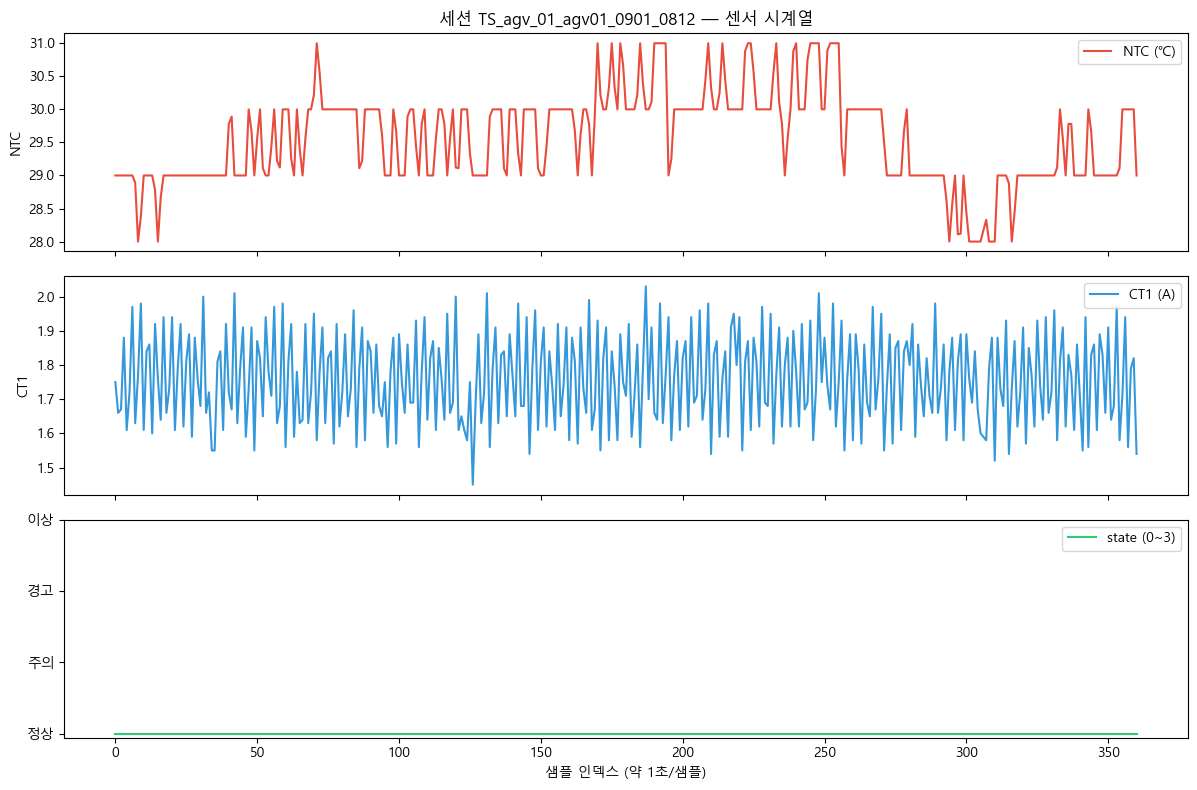

In [7]:
def plot_session_timeseries(df: pd.DataFrame, session: str):
    """한 세션의 NTC·CT1·state를 3단 subplot으로 시각화."""
    sub = df[df["session"] == session].copy()
    if sub.empty:
        print(f"세션 없음: {session}")
        return
    x = np.arange(len(sub))
    setup_korean_matplotlib()
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(x, sub["ntc"], color="#e74c3c", label="NTC (℃)")
    axes[0].set_ylabel("NTC")
    axes[0].legend(loc="upper right")
    axes[0].set_title(f"세션 {session} — 센서 시계열")
    axes[1].plot(x, sub["ct1"], color="#3498db", label="CT1 (A)")
    axes[1].set_ylabel("CT1")
    axes[1].legend(loc="upper right")
    state_num = sub["state"].replace("", "0").astype(int)
    axes[2].step(x, state_num, where="mid", color="#2ecc71", label="state (0~3)")
    axes[2].set_yticks([0, 1, 2, 3])
    axes[2].set_yticklabels(["정상", "주의", "경고", "이상"])
    axes[2].set_xlabel("샘플 인덱스 (약 1초/샘플)")
    axes[2].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


demo_session = ts_df["session"].iloc[0]
plot_session_timeseries(ts_df, demo_session)


## 5. 슬라이딩 윈도우 → 한글 요약 청크

시계열을 `WINDOW_SIZE` 길이로 잘라 **검색용 한글 문장**으로 변환합니다.
SigLIP2는 이 문장을 텍스트 임베딩해 Qdrant에 저장합니다.

### 슬라이딩 윈도우 개념

- 긴 시계열 전체는 임베딩하기 어렵고 검색도 부정확합니다.
- **30샘플(약 30초) 구간**마다 "NTC 29→32℃, CT1 최대 1.8A…" 같은 문장을 만듭니다.
- `WINDOW_STEP=15`이면 인접 윈도우가 50% 겹쳐 **경계 구간**도 놓치지 않습니다.


In [8]:
def trend_text(name: str, trend_val) -> str:
    """trend 코드(-1/0/1) → 'NTC 상승' 같은 한글 조각."""
    if trend_val is None or (isinstance(trend_val, float) and np.isnan(trend_val)):
        return ""
    label = TREND_LABELS.get(str(int(trend_val)), "")
    return f"{name} {label}" if label else ""


def summarize_window(win: pd.DataFrame) -> str:
    """윈도우 DataFrame → SigLIP2 검색용 한글 요약 문장."""
    session = win["session"].iloc[0]
    t0 = win["collection_time"].iloc[0] if "collection_time" in win else win["sample_id"].iloc[0]
    t1 = win["collection_time"].iloc[-1] if "collection_time" in win else win["sample_id"].iloc[-1]
    ntc_s, ntc_e = win["ntc"].iloc[0], win["ntc"].iloc[-1]
    ct1_max = win["ct1"].max()
    pm10_max = win["pm10"].max()
    state_nums = win["state"].replace("", "0").astype(int)
    peak_state = STATE_LABELS.get(str(state_nums.max()), "미라벨")
    ir_max = win["ir_max"].max() if "ir_max" in win.columns else np.nan
    trends = []
    for col in ("ntc_trend", "ct1_trend"):
        if col in win.columns:
            mode = win[col].mode()
            if len(mode):
                trends.append(trend_text(col.replace("_trend", "").upper(), mode.iloc[0]))
    trend_str = ", ".join(t for t in trends if t)
    ir_part = f", 열화상 최대 {ir_max:.1f}℃" if not np.isnan(ir_max) else ""
    return (
        f"세션 {session}, 구간 {t0}~{t1}: "
        f"NTC {ntc_s:.1f}→{ntc_e:.1f}℃, CT1 최대 {ct1_max:.2f}A, PM10 최대 {pm10_max:.1f}, "
        f"열화 상태 최고 {peak_state}{ir_part}"
        + (f", {trend_str}" if trend_str else "")
    )


def build_window_chunks(
    df: pd.DataFrame,
    window_size: int = WINDOW_SIZE,
    step: int = WINDOW_STEP,
) -> list[dict]:
    """세션별 슬라이딩 윈도우 → 검색·연계용 chunk dict 목록."""
    chunks = []
    for session, grp in df.groupby("session", sort=False):
        grp = grp.reset_index(drop=True)
        for start in range(0, len(grp) - window_size + 1, step):
            win = grp.iloc[start : start + window_size]
            summary = summarize_window(win)
            rep = win.iloc[len(win) // 2]  # 대표 sample (열화상 연계용)
            peak_idx = win["state"].replace("", "0").astype(int).idxmax()
            peak_row = win.loc[peak_idx]
            chunks.append({
                "window_id": f"{session}_{start:04d}",
                "session": session,
                "split": win["split"].iloc[0],
                "start_idx": int(start),
                "end_idx": int(start + window_size - 1),
                "sample_start": win["sample_id"].iloc[0],
                "sample_end": win["sample_id"].iloc[-1],
                "sample_rep": rep["sample_id"],
                "image_path": rep["image_path"],
                "peak_sample_id": peak_row["sample_id"],
                "peak_state": peak_row["state"],
                "peak_state_label": peak_row["state_label"],
                "ntc_delta": float(win["ntc"].iloc[-1] - win["ntc"].iloc[0]),
                "ct1_max": float(win["ct1"].max()),
                "summary": summary,
            })
    return chunks


windows = build_window_chunks(ts_df)
WINDOWS_CACHE.write_text(json.dumps(windows, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"윈도우 청크: {len(windows)}개")
for w in windows[:3]:
    print(f"  [{w['window_id']}] {w['summary'][:80]}...")


윈도우 청크: 92개
  [TS_agv_01_agv01_0901_0812_0000] 세션 TS_agv_01_agv01_0901_0812, 구간 08:12:40~nan: NTC 29.0→29.0℃, CT1 최대 1.98A, PM1...
  [TS_agv_01_agv01_0901_0812_0015] 세션 TS_agv_01_agv01_0901_0812, 구간 nan~nan: NTC 28.0→29.0℃, CT1 최대 2.01A, PM10 최대 ...
  [TS_agv_01_agv01_0901_0812_0030] 세션 TS_agv_01_agv01_0901_0812, 구간 08:13:10~nan: NTC 29.0→30.0℃, CT1 최대 2.01A, PM1...


## 6. SigLIP2 텍스트 임베딩 → Qdrant 인덱싱

13번 **열화상 컬렉션**과 별도로 `conveyor_timeseries_siglip2` 컬렉션을 만듭니다.
이미지가 아닌 **시계열 요약 문장**만 텍스트 임베딩합니다.

| 13번 vs 14번 | 임베딩 대상 | Qdrant 컬렉션 |
|-------------|------------|---------------|
| 13번 | 열화상 PNG | `conveyor_condition_siglip2` |
| 14번 | 한글 요약 문장 | `conveyor_timeseries_siglip2` |


In [9]:
class SigLIP2Encoder:
    """SigLIP2 텍스트 전용 인코더 (14번은 이미지 임베딩 미사용)."""

    def __init__(self, model_id: str = SIGLIP2_MODEL_ID):
        dtype = torch.float16 if device == "cuda" else torch.float32
        self.model = AutoModel.from_pretrained(model_id, torch_dtype=dtype).to(device).eval()
        self.processor = AutoProcessor.from_pretrained(model_id)
        print(f"SigLIP2 로딩: {model_id} ({device})")

    @staticmethod
    def _pool(output):
        return output if isinstance(output, torch.Tensor) else output.pooler_output

    @torch.no_grad()
    def encode_texts(self, texts: list[str]) -> np.ndarray:
        inputs = self.processor(
            text=texts, padding="max_length", truncation=True,
            max_length=64, return_tensors="pt",  # SigLIP2 텍스트 상한 64토큰
        ).to(device)
        feats = self._pool(self.model.get_text_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)  # L2 정규화 → 코사인 유사도
        return feats.cpu().numpy()


def get_qdrant_client() -> QdrantClient:
    global qdrant_client
    if qdrant_client is None:
        qdrant_client = QdrantClient(path=str(QDRANT_DIR))
    return qdrant_client


def window_to_payload(w: dict) -> dict:
    """Qdrant payload — 검색 결과 표시·하이브리드 연계에 필요한 필드."""
    return {
        "window_id": w["window_id"],
        "session": w["session"],
        "split": w["split"],
        "summary": w["summary"],
        "sample_rep": w["sample_rep"],
        "peak_sample_id": w["peak_sample_id"],
        "peak_state": w["peak_state"],
        "peak_state_label": w["peak_state_label"],
        "image_path": w["image_path"],
        "ntc_delta": w["ntc_delta"],
        "ct1_max": w["ct1_max"],
        "sample_start": w["sample_start"],
        "sample_end": w["sample_end"],
    }


def index_windows_to_qdrant(
    chunks: list[dict],
    encoder: SigLIP2Encoder,
    batch_size: int = SIGLIP2_BATCH_SIZE,
    recreate: bool = False,
) -> int:
    """윈도우 청크를 SigLIP2 텍스트 임베딩 후 Qdrant에 upsert."""
    client = get_qdrant_client()
    if recreate and client.collection_exists(TS_COLLECTION_NAME):
        client.delete_collection(TS_COLLECTION_NAME)
    if not client.collection_exists(TS_COLLECTION_NAME):
        client.create_collection(
            collection_name=TS_COLLECTION_NAME,
            vectors_config=models.VectorParams(size=EMBED_DIM, distance=models.Distance.COSINE),
        )
        print(f"컬렉션 생성: {TS_COLLECTION_NAME}")
    total = 0
    for i in tqdm(range(0, len(chunks), batch_size), desc="시계열 인덱싱"):
        batch = chunks[i : i + batch_size]
        texts = [c["summary"] for c in batch]
        embeddings = encoder.encode_texts(texts)
        points = []
        for w, emb in zip(batch, embeddings):
            pid = str(uuid.uuid5(uuid.NAMESPACE_DNS, w["window_id"]))
            points.append(models.PointStruct(
                id=pid, vector=emb.tolist(), payload=window_to_payload(w),
            ))
        client.upsert(collection_name=TS_COLLECTION_NAME, points=points)
        total += len(points)
    print(f"시계열 인덱싱 완료: {total}건")
    return total


siglip_encoder = SigLIP2Encoder()
index_windows_to_qdrant(windows, siglip_encoder, recreate=REBUILD_TS_INDEX)


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SigLIP2 로딩: google/siglip2-so400m-patch14-384 (cpu)
컬렉션 생성: conveyor_timeseries_siglip2


시계열 인덱싱:   0%|          | 0/6 [00:00<?, ?it/s]

시계열 인덱싱 완료: 92건


92

## 7. 한글 시계열 검색

한글 질문 → SigLIP2 텍스트 벡터 → Qdrant Top-k **시계열 구간** 검색.

### 질의 작성 팁

- 센서 이름(NTC, CT1)과 상태(상승, 이상)를 **자연어**로 쓰면 됩니다.
- `state_filter`로 peak_state(0~3)를 제한할 수 있습니다.

예시 질의:
- "NTC 온도가 상승한 구간"
- "CT1 전류가 높은 이상 구간"
- "열화 상태가 경고 이상인 구간"


In [10]:
def search_timeseries_windows(
    query: str,
    encoder: SigLIP2Encoder,
    client: QdrantClient,
    top_k: int = TOP_K,
    state_filter: str | None = None,
) -> list[dict]:
    """한글 query → SigLIP2 벡터 → Qdrant 코사인 Top-k."""
    query_vec = encoder.encode_texts([query])[0].tolist()
    qfilter = None
    if state_filter is not None:
        qfilter = models.Filter(must=[
            models.FieldCondition(key="peak_state", match=models.MatchValue(value=state_filter))
        ])
    response = client.query_points(
        collection_name=TS_COLLECTION_NAME,
        query=query_vec,
        query_filter=qfilter,
        limit=top_k,
        with_payload=True,
    )
    return [
        {"rank": i, "score": float(p.score), "payload": p.payload}
        for i, p in enumerate(response.points, 1)
    ]


def show_timeseries_hits(hits: list[dict]):
    """검색 hit 요약 문장 출력 + DataFrame 표."""
    setup_korean_matplotlib()
    rows = []
    for h in hits:
        p = h["payload"]
        rows.append({
            "rank": h["rank"],
            "score": round(h["score"], 4),
            "session": p["session"],
            "구간": f"{p['sample_start']} ~ {p['sample_end']}",
            "peak_state": p["peak_state_label"],
            "ct1_max": p["ct1_max"],
            "ntc_delta": round(p["ntc_delta"], 2),
        })
        print(f"#{h['rank']} score={h['score']:.3f} | {p['summary']}")
    display(pd.DataFrame(rows))


TS_QUERY = "CT1 전류가 높고 열화 이상 징후가 있는 구간"
ts_hits = search_timeseries_windows(TS_QUERY, siglip_encoder, get_qdrant_client(), top_k=TOP_K)
print(f"Query: {TS_QUERY}")
show_timeseries_hits(ts_hits)


Query: CT1 전류가 높고 열화 이상 징후가 있는 구간
#1 score=0.840 | 세션 TS_agv_03_agv03_1027_1439, 구간 nan~nan: NTC 39.8→43.1℃, CT1 최대 2.19A, PM10 최대 70.0, 열화 상태 최고 주의, 열화상 최대 80.5℃, NTC 상승, CT1 상승
#2 score=0.838 | 세션 TS_agv_05_agv05_0903_0409, 구간 nan~nan: NTC 51.6→56.9℃, CT1 최대 133.37A, PM10 최대 86.0, 열화 상태 최고 이상, 열화상 최대 111.8℃, NTC 상승, CT1 상승
#3 score=0.838 | 세션 TS_agv_01_agv01_0901_0812, 구간 08:14:40~nan: NTC 29.1→29.1℃, CT1 최대 2.01A, PM10 최대 52.0, 열화 상태 최고 정상, 열화상 최대 49.9℃, NTC 상승, CT1 상승


,rank,score,session,구간,peak_state,ct1_max,ntc_delta
0,1,0.8404,TS_agv_03_agv03_1027_1439,agv03_1027_144215 ~ agv03_1027_144244,주의,2.19,3.30
1,2,0.8378,TS_agv_05_agv05_0903_0409,agv05_0903_041415 ~ agv05_0903_041444,이상,133.37,5.27
2,3,0.8376,TS_agv_01_agv01_0901_0812,agv01_0901_081440 ~ agv01_0901_081509,정상,2.01,-0.01


## 8. 하이브리드: 시계열 hit → 열화상 연계

검색된 시계열 구간의 **대표 열화상 PNG**(13번에서 생성)를 함께 표시합니다.
Visual(13번) + Time-Series(14번)를 `sample_id`로 연결하는 **하이브리드 RAG** 패턴입니다.

| 연계 키 | 경로 |
|---------|------|
| `sample_rep` | 윈도우 중앙 샘플의 열화상 PNG |
| `peak_sample_id` | 구간 내 최고 state 샘플 |


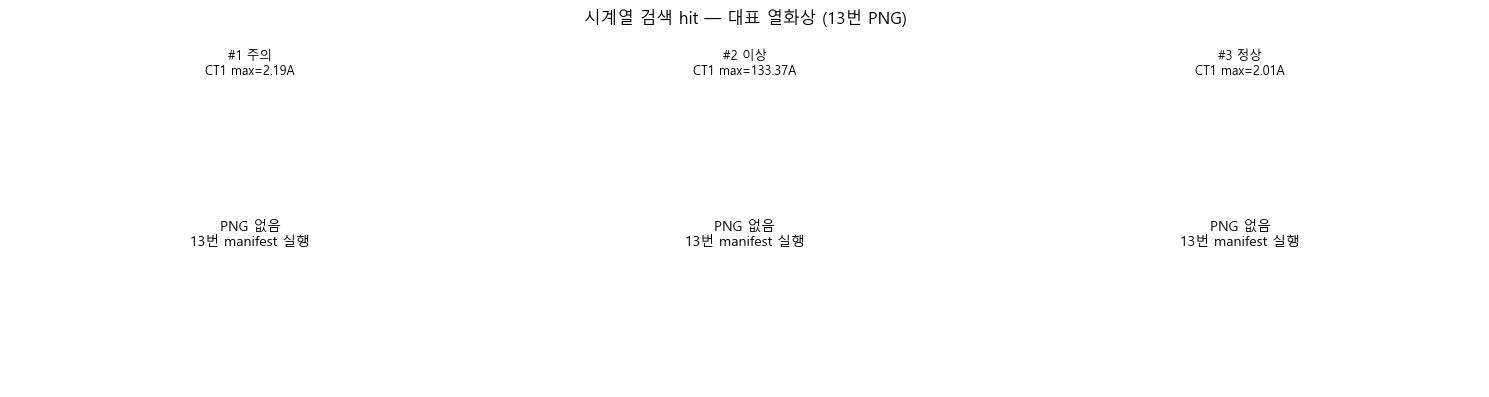

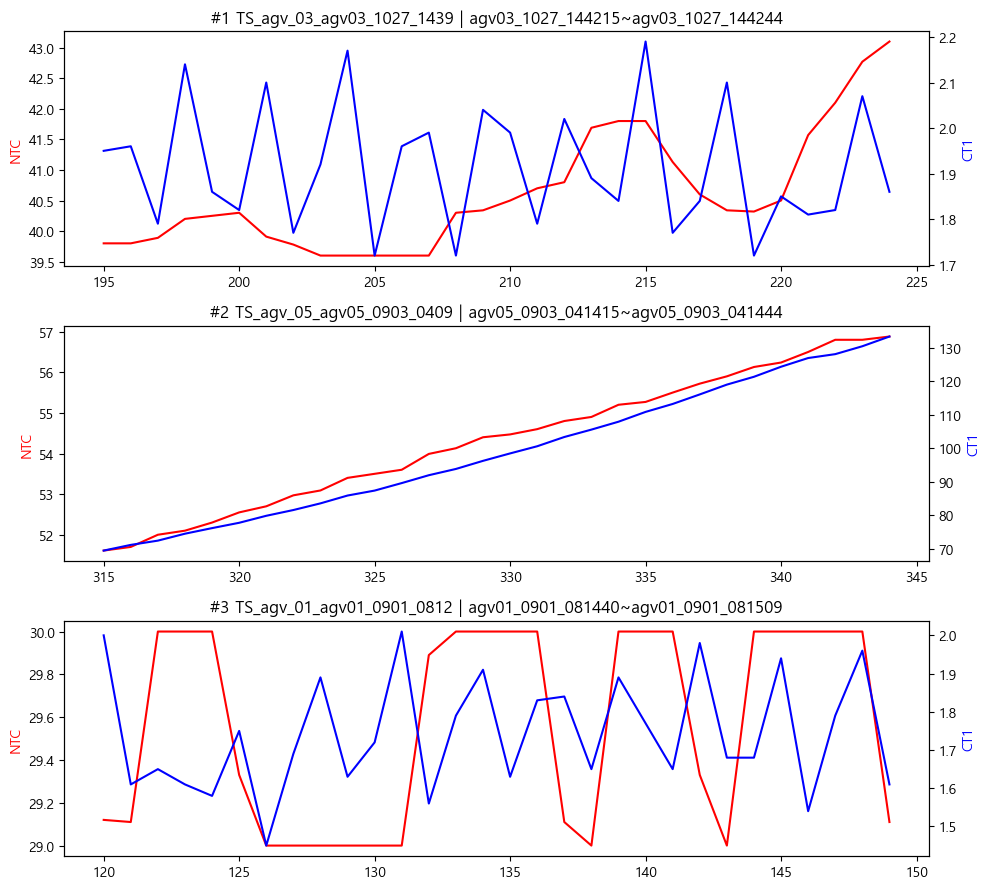

In [12]:
def show_hybrid_hits(hits: list[dict], ts_df: pd.DataFrame):
    """시계열 hit → 대표 열화상 + 해당 구간 NTC·CT1 미니 차트."""
    setup_korean_matplotlib()
    n = len(hits)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, h in zip(axes, hits):
        p = h["payload"]
        img_path = Path(p["image_path"])
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        else:
            ax.text(0.5, 0.5, "PNG 없음\n13번 manifest 실행", ha="center", va="center")
        ax.set_title(
            f"#{h['rank']} {p['peak_state_label']}\n"
            f"CT1 max={p['ct1_max']:.2f}A",
            fontsize=9,
        )
        ax.axis("off")
    plt.suptitle("시계열 검색 hit — 대표 열화상 (13번 PNG)")
    plt.tight_layout()
    plt.show()

    # hit 세션의 NTC·CT1 미니 차트
    fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n))
    if n == 1:
        axes = [axes]
    for ax, h in zip(axes, hits):
        p = h["payload"]
        sub = ts_df[ts_df["session"] == p["session"]].reset_index(drop=True)
        s, e = p["sample_start"], p["sample_end"]
        mask = (sub["sample_id"] >= s) & (sub["sample_id"] <= e)
        win = sub[mask]
        ax2 = ax.twinx()
        ax.plot(win.index, win["ntc"], "r-", label="NTC")
        ax2.plot(win.index, win["ct1"], "b-", label="CT1")
        ax.set_title(f"#{h['rank']} {p['session']} | {s}~{e}")
        ax.set_ylabel("NTC", color="r")
        ax2.set_ylabel("CT1", color="b")
    plt.tight_layout()
    plt.show()


show_hybrid_hits(ts_hits, ts_df)


## 9. Qwen3-VL 시계열·열화상 분석

검색된 시계열 요약 + 대표 열화상을 Qwen3-VL에 넣어 **한글 분석문**을 생성합니다.
SigLIP2와 VRAM 충돌을 피하기 위해 분석 전 SigLIP2를 메모리에서 해제합니다.

> **VRAM 주의**: SigLIP2 + Qwen3-VL을 동시에 GPU에 올리면 OOM이 날 수 있습니다.
> `release_siglip()` → `load_qwen()` 순서로 모델을 교체합니다.


In [16]:
def release_siglip():
    """SigLIP2 모델 해제 — Qwen3-VL 로딩 전 VRAM 확보."""
    global siglip_encoder
    if siglip_encoder is not None:
        del siglip_encoder
        siglip_encoder = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


def load_qwen():
    """Qwen3-VL 지연 로딩 (싱글톤)."""
    global qwen_model, qwen_processor
    if qwen_model is not None:
        return qwen_model, qwen_processor
    dtype = torch.float16 if device == "cuda" else torch.float32
    qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID, torch_dtype=dtype, device_map="auto" if device == "cuda" else None,
    )
    qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
    if device != "cuda":
        qwen_model = qwen_model.to(device)
    qwen_model.eval()
    return qwen_model, qwen_processor


def analyze_timeseries_with_qwen(query: str, hits: list[dict], max_windows: int = 2) -> str:
    """시계열 요약 + 열화상 이미지 → Qwen3-VL 한글 분석문."""
    release_siglip()
    model, processor = load_qwen()
    summaries = []
    images = []
    for h in hits[:max_windows]:
        p = h["payload"]
        summaries.append(f"- [{p['window_id']}] {p['summary']}")
        img_path = Path(p["image_path"])
        if img_path.exists():
            images.append(Image.open(img_path).convert("RGB"))
    if not images:
        return "열화상 PNG가 없습니다. 13번 노트북에서 manifest·PNG 변환을 먼저 실행하세요."
    prompt = (
        f"질문: {query}\n\n"
        f"검색된 시계열 구간:\n" + "\n".join(summaries) + "\n\n"
        "위 시계열 요약과 열화상 이미지를 종합해 이송장치 이상·열화 여부를 "
        "한국어로 간결히 분석하세요. NTC·CT1·상태 변화 근거를 포함하세요."
    )
    messages = [{"role": "user", "content": [
        *[{"type": "image", "image": img} for img in images],
        {"type": "text", "text": prompt},
    ]}]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device)
    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=512, do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    return processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()


# VRAM 여유 있을 때만 실행 (주석 해제)
answer = analyze_timeseries_with_qwen(TS_QUERY, ts_hits)
display(Markdown(answer))
print("Qwen3-VL 분석은 VRAM 여유 시 위 주석을 해제해 실행하세요.")


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

열화상 PNG가 없습니다. 13번 노트북에서 manifest·PNG 변환을 먼저 실행하세요.

Qwen3-VL 분석은 VRAM 여유 시 위 주석을 해제해 실행하세요.


## 10. 통합 파이프라인

`run_timeseries_rag()` — 시계열 검색 → 차트·열화상 → (선택) Qwen3-VL.

| 인자 | 기본값 | 설명 |
|------|--------|------|
| `use_qwen` | False | True면 Qwen3-VL 분석까지 실행 |
| `state_filter` | None | peak_state 필터 (예: "3"=이상) |


#1 score=0.802 | 세션 TS_agv_01_agv01_0901_0812, 구간 08:14:40~nan: NTC 29.1→29.1℃, CT1 최대 2.01A, PM10 최대 52.0, 열화 상태 최고 정상, 열화상 최대 49.9℃, NTC 상승, CT1 상승
#2 score=0.800 | 세션 TS_agv_01_agv01_0901_0812, 구간 08:13:10~nan: NTC 29.0→30.0℃, CT1 최대 2.01A, PM10 최대 52.0, 열화 상태 최고 정상, 열화상 최대 46.3℃, NTC 상승, CT1 상승
#3 score=0.799 | 세션 TS_agv_01_agv01_0901_0812, 구간 08:15:40~nan: NTC 30.0→31.0℃, CT1 최대 2.03A, PM10 최대 51.0, 열화 상태 최고 정상, 열화상 최대 50.7℃, NTC 상승, CT1 상승


,rank,score,session,구간,peak_state,ct1_max,ntc_delta
0,1,0.8022,TS_agv_01_agv01_0901_0812,agv01_0901_081440 ~ agv01_0901_081509,정상,2.01,-0.01
1,2,0.8003,TS_agv_01_agv01_0901_0812,agv01_0901_081310 ~ agv01_0901_081339,정상,2.01,1.00
2,3,0.7989,TS_agv_01_agv01_0901_0812,agv01_0901_081540 ~ agv01_0901_081609,정상,2.03,1.00


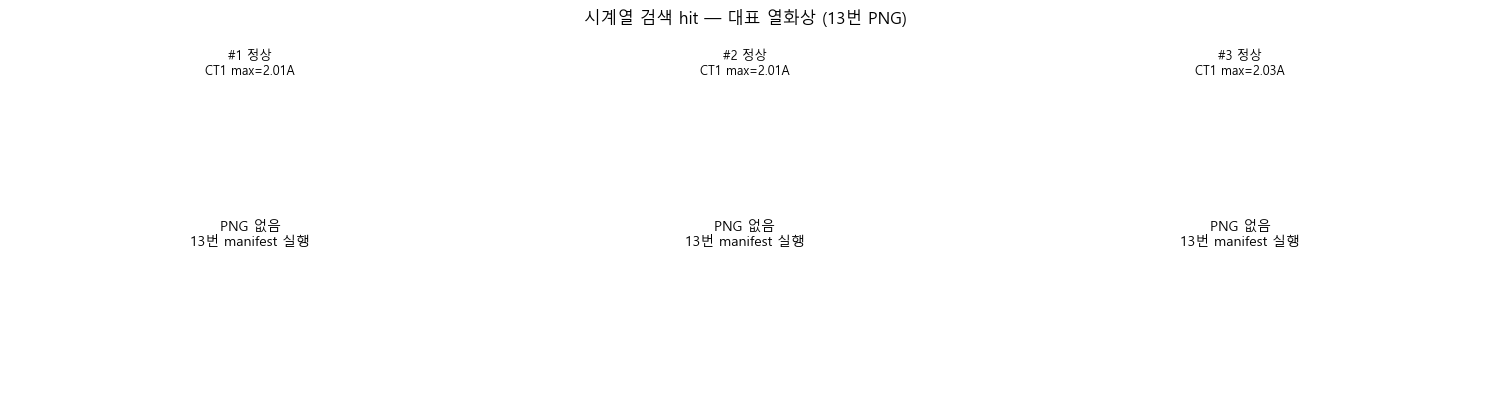

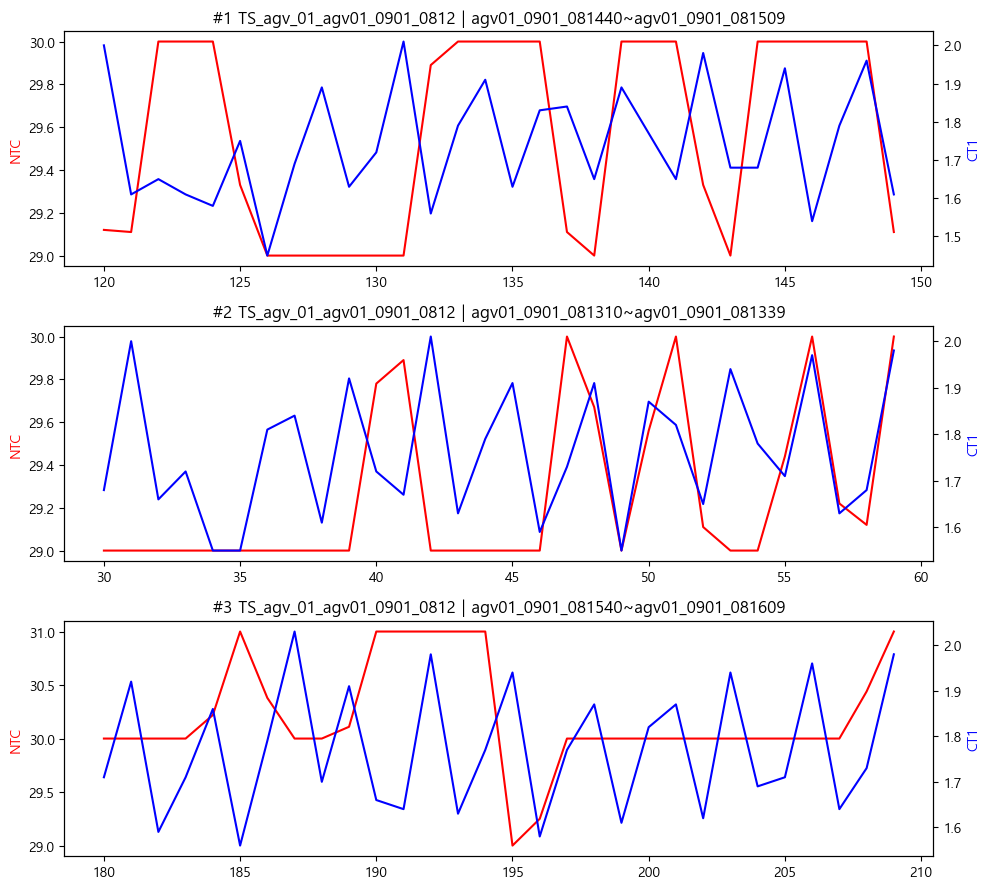

{'query': 'NTC 온도 상승과 전류 이상이 동시에 나타난 구간',
 'hits': [{'rank': 1,
   'score': 0.8022316436499344,
   'payload': {'window_id': 'TS_agv_01_agv01_0901_0812_0120',
    'session': 'TS_agv_01_agv01_0901_0812',
    'split': 'Training',
    'summary': '세션 TS_agv_01_agv01_0901_0812, 구간 08:14:40~nan: NTC 29.1→29.1℃, CT1 최대 2.01A, PM10 최대 52.0, 열화 상태 최고 정상, 열화상 최대 49.9℃, NTC 상승, CT1 상승',
    'sample_rep': 'agv01_0901_081455',
    'peak_sample_id': 'agv01_0901_081440',
    'peak_state': '0',
    'peak_state_label': '정상',
    'image_path': 'C:\\MyCursorLab\\09_Visual_RAG\\data\\conveyor_condition_monitoring\\thermal_images\\Training\\TS_agv_01_agv01_0901_0812\\agv01_0901_081455.png',
    'ntc_delta': -0.010000000000001563,
    'ct1_max': 2.01,
    'sample_start': 'agv01_0901_081440',
    'sample_end': 'agv01_0901_081509'}},
  {'rank': 2,
   'score': 0.8003236153094733,
   'payload': {'window_id': 'TS_agv_01_agv01_0901_0812_0030',
    'session': 'TS_agv_01_agv01_0901_0812',
    'split': 'Training',
  

In [15]:
def run_timeseries_rag(
    query: str,
    top_k: int = TOP_K,
    use_qwen: bool = False,
    state_filter: str | None = None,
) -> dict:
    """한글 Query → 시계열 윈도우 검색 → 하이브리드 시각화 → (선택) Qwen3-VL"""
    global siglip_encoder
    if siglip_encoder is None:
        print("SigLIP2 재로딩...")
        siglip_encoder = SigLIP2Encoder()
    hits = search_timeseries_windows(
        query, siglip_encoder, get_qdrant_client(),
        top_k=top_k, state_filter=state_filter,
    )
    show_timeseries_hits(hits)
    show_hybrid_hits(hits, ts_df)
    result = {"query": query, "hits": hits, "answer": None}
    if use_qwen and hits:
        result["answer"] = analyze_timeseries_with_qwen(query, hits)
        display(Markdown(result["answer"]))
    return result


# 기본: 시계열 검색 + 하이브리드 차트만
run_timeseries_rag("NTC 온도 상승과 전류 이상이 동시에 나타난 구간", top_k=3, use_qwen=False)


## 요약·트러블슈팅

### 실행 순서

| 순서 | 섹션 | 핵심 작업 |
|------|------|-----------|
| 선행 | 13번 | ZIP 추출 + (권장) manifest·PNG·열화상 Qdrant |
| 0 | 환경 설정 | 경로·윈도우·컬렉션명 |
| 1 | 데이터 준비 | `scan_dataset_records()` |
| 2 | metadata 파싱 | EAV → trend·ir_max·외부센서 |
| 3 | 세션 시계열 | session + sample_id 시간 정렬 |
| 4 | EDA | NTC·CT1·state 시계열 차트 |
| 5 | 윈도우 청크 | 한글 요약 문장 생성 |
| 6 | Qdrant 인덱싱 | SigLIP2 텍스트 임베딩 |
| 7~10 | 검색·하이브리드·통합 | `run_timeseries_rag()` |

### 자주 겪는 문제

| 증상 | 해결 |
|------|------|
| `Other/metadata` 없음 | ZIP 압축 해제 셀 먼저 |
| 열화상 PNG 없음 | 13번 manifest·BIN→PNG 실행 |
| `AlreadyLocked` (Qdrant) | Kernel Restart (13번·14번 동시 open 주의) |
| 검색 결과 편향 | `DEMO_MODE=False`, `MAX_SESSIONS` 늘리기 |
| Qwen OOM | `use_qwen=False`로 검색만 먼저 확인 |
| SigLIP2 재로딩 느림 | Qwen 실행 후 `run_timeseries_rag`가 SigLIP2를 다시 로드함 |

### 13번과의 역할 분담

| | 13번 | 14번 |
|---|------|------|
| 검색 대상 | 열화상 PNG | 시계열 요약 문장 |
| Qdrant 컬렉션 | `conveyor_condition_siglip2` | `conveyor_timeseries_siglip2` |
| 연계 키 | sample_id | window → sample_rep → PNG |
